# 01 — Build case-level features

Streams `Event Log.csv` → `data/case_features.parquet` (complexity metrics + LOS).

**Full build (terminal):**

```bash
cd Project
source .venv/bin/activate
pip install -r requirements.txt
python src/build_features.py --case-type cv --closed-only
```

**Dev sample:**

```bash
python src/build_features.py --sample-rows 200000 --case-type cv --closed-only
```

In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path("..").resolve()
PARQUET = ROOT / "data" / "case_features.parquet"

if not PARQUET.exists():
    raise FileNotFoundError(
        "Run first: python src/build_features.py --sample-rows 200000 --case-type cv --closed-only"
    )

df = pd.read_parquet(PARQUET)
df = df[df["los_days"].notna()].copy()
print(f"cases: {len(df):,}")
df.head()

cases: 151,640


,case_status,case_type,nature_suit,city,is_mdl,District_Judge,Magistrate_Judge,plaintiffs_count,Defendants_count,plaintiffs_counsels_count,...,z_n_activity_types,z_activity_entropy,z_n_attribute_flags,z_rework_ratio,z_time_gaps_std,z_party_load,z_counsel_load,z_pro_se_parties,complexity_index,judge_caseload
0,closed,cv,530 General,Chicago,False,SJ000241,,2.0,1.0,5.0,...,0.278311,-0.029036,0.065402,0.667105,0.222818,-0.088458,-0.081710,0.880335,0.329793,4765
1,closed,cv,440 Other Civil Rights,Chicago,False,SJ000178,,1.0,2.0,1.0,...,0.278311,0.296663,0.309501,1.019375,-0.101033,-0.088458,-0.112164,2.231749,0.514795,4574
2,closed,cv,440 Other Civil Rights,Chicago,False,SJ000197,,1.0,5.0,4.0,...,1.591141,1.073982,1.774096,1.238971,-0.347861,0.025009,0.101015,-0.471080,1.116212,2058
3,closed,cv,530 General,Chicago,False,SJ000250,,2.0,1.0,3.0,...,-0.159299,-0.694658,-0.422797,0.506983,-0.088427,-0.088458,-0.142618,0.880335,0.088872,1942
4,closed,cv,900 Appeal Of Fee Determination Under Equal Ac...,Chicago,False,SJ000255,,1.0,1.0,0.0,...,-1.472129,-1.519776,-1.399194,-1.094242,0.790506,-0.126281,-0.264434,2.231749,-0.379331,2284


,count,mean,std,min,25%,50%,75%,max
n_events,151640.0,2.543926e+01,38.901699,1.000000,7.000000,15.000000,29.000000,5875.000000
n_activity_types,151640.0,6.364020e+00,2.285140,1.000000,5.000000,6.000000,8.000000,17.000000
n_motions,151640.0,4.150739e+00,7.963227,0.000000,1.000000,2.000000,5.000000,1012.000000
activity_entropy,151640.0,1.524822e+00,0.319193,0.000000,1.351039,1.581094,1.747557,2.397895
party_load,151640.0,5.338773e+00,26.439317,2.000000,2.000000,3.000000,5.000000,4233.000000
rework_ratio,151640.0,5.347409e-01,0.260217,0.000000,0.363636,0.583333,0.741935,0.997447
complexity_index,151640.0,2.399089e-17,0.572888,-1.258397,-0.346095,-0.062836,0.234521,76.694254
los_days,151640.0,4.251371e+02,514.308066,0.000000,102.000000,253.000000,552.000000,6827.000000


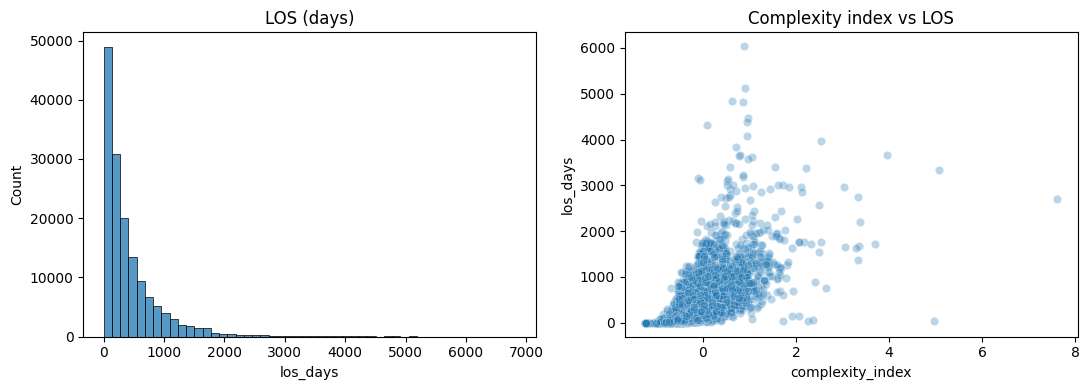

In [5]:
COMPLEXITY = [
    "n_events", "n_activity_types", "n_motions", "activity_entropy",
    "party_load", "rework_ratio", "complexity_index",
]

display(df[COMPLEXITY + ["los_days"]].describe().T)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(df["los_days"], bins=50, ax=axes[0])
axes[0].set_title("LOS (days)")
sns.scatterplot(
    data=df.sample(min(5000, len(df))),
    x="complexity_index", y="los_days", alpha=0.3, ax=axes[1],
)
axes[1].set_title("Complexity index vs LOS")
plt.tight_layout()

Text(0.5, 1.0, 'Complexity features vs LOS')

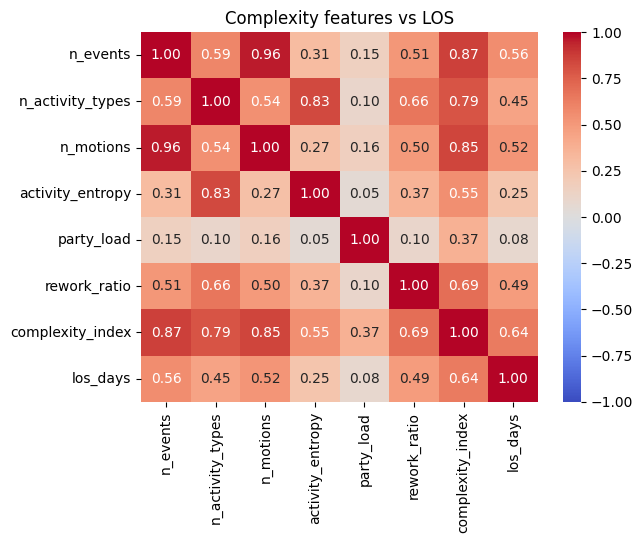

In [3]:
cols = [c for c in COMPLEXITY if c in df.columns] + ["los_days"]
corr = df[cols].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Complexity features vs LOS")